# CoG vs Fundamentalness Correlation Analysis (COMPREHENSIVE)

This notebook correlates LLM polarization **depth** (Center of Gravity) with **ALL fundamentalness measures** computed from GSS survey data.

**Fundamentalness measures include:**

**1. Network Centrality (7 variants × 9 centrality types)**
- Variants: complete, thresh_0.05/0.1/0.15/0.2, complete_log, complete_squared
- Centralities: betweenness, betweenness_unw, closeness, harmonic, eigenvector, pagerank, degree, strength, katz

**2. Tree Measures (Chow-Liu MST)**
- tree_betweenness
- For each root selection (max_neighbor_mi, max_degree, center):
  - depth, depth_inv, depth_norm, subtree, hierarchy

**3. MI/Correlation Based**
- mi_sum, mi_mean, mi_max
- corr_abs_sum, corr_abs_mean

**Models:** Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B  
**CoG normalization:** Z-score within each model before averaging

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mutual_info_score
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
LLM_RESULTS_DIR = Path('/project/jevans/maxzhuyt/gss_polarization/llm_polarization/results')
GSS_DEPTH_DIR = Path('/project/jevans/maxzhuyt/gss_polarization/question_fundamentalness')
RESULTS_DIR = GSS_DEPTH_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# LLM combined results with CoG
LLM_COMBINED_FILE = LLM_RESULTS_DIR / 'df_gss_2cat_combined_20260128_230153.pkl'

# Models to use (4 models only)
MODELS_TO_USE = ['Llama-3.1-8B', 'Gemma-2-9b', 'Mistral-7B-v0.2', 'Qwen3-8B']

print("Configuration:")
print(f"  LLM results: {LLM_COMBINED_FILE}")
print(f"  GSS data dir: {GSS_DEPTH_DIR}")
print(f"  Models: {MODELS_TO_USE}")

Configuration:
  LLM results: /project/jevans/maxzhuyt/gss_polarization/llm_polarization/results/df_gss_2cat_combined_20260128_230153.pkl
  GSS data dir: /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness
  Models: ['Llama-3.1-8B', 'Gemma-2-9b', 'Mistral-7B-v0.2', 'Qwen3-8B']


## 1. Load Data

In [2]:
# Load LLM results with CoG
df_llm = pd.read_pickle(LLM_COMBINED_FILE)
print(f"LLM data: {len(df_llm)} rows")
print(f"All models: {df_llm['model'].unique().tolist()}")
print(f"Categories: {df_llm['category'].unique().tolist()}")

# Filter to 4 models only
df_llm = df_llm[df_llm['model'].isin(MODELS_TO_USE)]
print(f"\nFiltered to {len(MODELS_TO_USE)} models: {len(df_llm)} rows")

# Normalize CoG within each model (z-score) before averaging
def normalize_cog(group):
    """Z-score normalize CoG within each model."""
    group = group.copy()
    mean_cog = group['Polarization_CoG'].mean()
    std_cog = group['Polarization_CoG'].std()
    if std_cog > 0:
        group['CoG_normalized'] = (group['Polarization_CoG'] - mean_cog) / std_cog
    else:
        group['CoG_normalized'] = 0
    return group

df_llm = df_llm.groupby('model', group_keys=False).apply(normalize_cog)

# Show normalization effect
print("\nCoG statistics per model (before and after normalization):")
for model in MODELS_TO_USE:
    model_data = df_llm[df_llm['model'] == model]
    raw_mean = model_data['Polarization_CoG'].mean()
    raw_std = model_data['Polarization_CoG'].std()
    norm_mean = model_data['CoG_normalized'].mean()
    norm_std = model_data['CoG_normalized'].std()
    print(f"  {model}: raw={raw_mean:.2f}±{raw_std:.2f}, normalized={norm_mean:.3f}±{norm_std:.3f}")

# Average normalized CoG across models per topic
df_cog = df_llm.groupby(['Topic', 'category']).agg({
    'Polarization_CoG': 'mean',
    'CoG_normalized': 'mean',
    'Avg_Mahalanobis': 'mean'
}).reset_index()
df_cog = df_cog.rename(columns={'Topic': 'variable'})
print(f"\nUnique topics with CoG: {len(df_cog)}")

LLM data: 1194 rows
All models: ['Llama-3.1-8B', 'DeepSeek-R1-Qwen-14B', 'Mistral-7B-v0.2', 'Gemma-2-9b', 'Qwen3-8B', 'Phi-4-reasoing-plus-7B']
Categories: ['public_issues', 'private_life']

Filtered to 4 models: 796 rows

CoG statistics per model (before and after normalization):
  Llama-3.1-8B: raw=16.85±0.81, normalized=-0.000±1.000
  Gemma-2-9b: raw=23.56±0.56, normalized=-0.000±1.000
  Mistral-7B-v0.2: raw=16.64±0.44, normalized=-0.000±1.000
  Qwen3-8B: raw=19.94±0.49, normalized=0.000±1.000

Unique topics with CoG: 199


In [3]:
# Load GSS survey data
df_gss = pd.read_csv(GSS_DEPTH_DIR / 'gss_2021_2024.csv')
print(f"GSS survey data: {len(df_gss)} respondents")

# Get variable lists from LLM combined file (only analyze variables with CoG data)
llm_public_vars = df_cog[df_cog['category'] == 'public_issues']['variable'].tolist()
llm_private_vars = df_cog[df_cog['category'] == 'private_life']['variable'].tolist()

print(f"\nVariables in LLM data:")
print(f"  Public issues: {len(llm_public_vars)}")
print(f"  Private life: {len(llm_private_vars)}")

# Filter to variables that exist in GSS survey data
public_vars = [v for v in llm_public_vars if v in df_gss.columns]
private_vars = [v for v in llm_private_vars if v in df_gss.columns]

print(f"\nVariables in both LLM and GSS data:")
print(f"  Public issues: {len(public_vars)}")
print(f"  Private life: {len(private_vars)}")

# Report variables missing from GSS
missing_public = set(llm_public_vars) - set(public_vars)
missing_private = set(llm_private_vars) - set(private_vars)
if missing_public:
    print(f"\n  Missing from GSS (public): {sorted(missing_public)[:10]}{'...' if len(missing_public) > 10 else ''}")
if missing_private:
    print(f"  Missing from GSS (private): {sorted(missing_private)[:10]}{'...' if len(missing_private) > 10 else ''}")

GSS survey data: 11066 respondents

Variables in LLM data:
  Public issues: 126
  Private life: 73

Variables in both LLM and GSS data:
  Public issues: 126
  Private life: 73


In [4]:
# Filter to variables that appear in at least 2 years (among 2021, 2022, 2024)
# A variable "appears" in a year if it has at least 30 valid responses (1-7 scale)
MIN_YEARS = 2
MIN_VALID_PER_YEAR = 30

def count_years_with_valid_data(df, variable, years=[2021, 2022, 2024], min_valid=MIN_VALID_PER_YEAR):
    """Count how many years a variable has valid data (values 1-7)."""
    years_with_data = 0
    for year in years:
        year_data = df[df['year'] == year][variable]
        # Valid GSS responses are 1-7; 0, 8, 9, negative, NA are invalid
        valid_mask = (year_data >= 1) & (year_data <= 7)
        if valid_mask.sum() >= min_valid:
            years_with_data += 1
    return years_with_data

print(f"Filtering to variables appearing in at least {MIN_YEARS} years...")
print(f"(Valid = at least {MIN_VALID_PER_YEAR} responses with values 1-7 in that year)\n")

# Check which years are in the data
available_years = sorted(df_gss['year'].unique())
print(f"Available years in GSS data: {available_years}")

# Filter public variables
public_year_counts = {v: count_years_with_valid_data(df_gss, v) for v in public_vars}
public_vars_filtered = [v for v in public_vars if public_year_counts[v] >= MIN_YEARS]
print(f"\nPublic issues:")
print(f"  Before filter: {len(public_vars)} variables")
print(f"  After filter (>={MIN_YEARS} years): {len(public_vars_filtered)} variables")
if len(public_vars) != len(public_vars_filtered):
    removed = [v for v in public_vars if public_year_counts[v] < MIN_YEARS]
    print(f"  Removed ({len(removed)}): {removed[:10]}{'...' if len(removed) > 10 else ''}")

# Filter private variables  
private_year_counts = {v: count_years_with_valid_data(df_gss, v) for v in private_vars}
private_vars_filtered = [v for v in private_vars if private_year_counts[v] >= MIN_YEARS]
print(f"\nPrivate life:")
print(f"  Before filter: {len(private_vars)} variables")
print(f"  After filter (>={MIN_YEARS} years): {len(private_vars_filtered)} variables")
if len(private_vars) != len(private_vars_filtered):
    removed = [v for v in private_vars if private_year_counts[v] < MIN_YEARS]
    print(f"  Removed ({len(removed)}): {removed[:10]}{'...' if len(removed) > 10 else ''}")

# Update variable lists
public_vars = public_vars_filtered
private_vars = private_vars_filtered

print(f"\nVariable lists updated for fundamentalness computation")

Filtering to variables appearing in at least 2 years...
(Valid = at least 30 responses with values 1-7 in that year)

Available years in GSS data: [np.int64(2021), np.int64(2022), np.int64(2024)]

Public issues:
  Before filter: 126 variables
  After filter (>=2 years): 76 variables
  Removed (50): ['abhelp1', 'abhelp2', 'abhelp3', 'abhelp4', 'balpos', 'carsgen', 'colhomo', 'colmil', 'dangroth', 'dangrslf']...

Private life:
  Before filter: 73 variables
  After filter (>=2 years): 48 variables
  Removed (25): ['eldfnce', 'fammhneg', 'hrsrelax', 'intsci', 'inttech', 'marmakid', 'marpakid', 'opclout', 'opeduc', 'ophrdwrk']...

Variable lists updated for fundamentalness computation


## 2. Compute Fundamentalness Measures

In [5]:
def preprocess_gss_data(df, variables, min_valid=100):
    """Preprocess GSS data for analysis."""
    # Filter to variables that exist in the data
    valid_vars = [v for v in variables if v in df.columns]
    
    # Convert invalid responses to NaN (GSS: 0, 8, 9, negative = invalid)
    df_subset = df[valid_vars].copy()
    for col in valid_vars:
        if pd.api.types.is_numeric_dtype(df_subset[col]):
            df_subset.loc[df_subset[col] <= 0, col] = np.nan
            df_subset.loc[df_subset[col] >= 8, col] = np.nan
    
    # Filter variables with enough valid responses
    valid_counts = df_subset.notna().sum()
    final_vars = valid_counts[valid_counts >= min_valid].index.tolist()
    
    return df_subset, final_vars


def compute_correlation_matrix(df, variables, min_samples=30):
    """Compute pairwise Spearman correlations."""
    n = len(variables)
    corr_matrix = pd.DataFrame(np.nan, index=variables, columns=variables)
    
    for i, q1 in enumerate(variables):
        corr_matrix.loc[q1, q1] = 1.0
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            x = df[q1].values
            y = df[q2].values
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() >= min_samples:
                corr, _ = stats.spearmanr(x[mask], y[mask])
                corr_matrix.loc[q1, q2] = corr
                corr_matrix.loc[q2, q1] = corr
    
    return corr_matrix


def compute_mi_matrix(df, variables, min_samples=30):
    """Compute pairwise mutual information."""
    n = len(variables)
    mi_matrix = pd.DataFrame(0.0, index=variables, columns=variables)
    
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            x = df[q1].values
            y = df[q2].values
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() >= min_samples:
                try:
                    mi = mutual_info_score(x[mask].astype(int), y[mask].astype(int))
                    mi_matrix.loc[q1, q2] = mi
                    mi_matrix.loc[q2, q1] = mi
                except:
                    pass
    
    return mi_matrix

In [6]:
def build_network_variants(corr_matrix, variables):
    """Build multiple network variants with different thresholds and transforms."""
    variants = {}
    
    # Variant 1: Complete graph, distance = 1 - |corr|
    G_complete = nx.Graph()
    G_complete.add_nodes_from(variables)
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            corr = corr_matrix.loc[q1, q2]
            if np.isnan(corr):
                abs_corr = 0.01
            else:
                abs_corr = max(abs(corr), 0.01)
            G_complete.add_edge(q1, q2, weight=abs_corr, distance=1-abs_corr)
    variants['complete'] = G_complete
    
    # Variant 2: Thresholded graphs
    for threshold in [0.05, 0.1, 0.15, 0.2]:
        G_thresh = nx.Graph()
        G_thresh.add_nodes_from(variables)
        for i, q1 in enumerate(variables):
            for j, q2 in enumerate(variables):
                if j <= i:
                    continue
                corr = corr_matrix.loc[q1, q2]
                if not np.isnan(corr) and abs(corr) > threshold:
                    abs_corr = abs(corr)
                    G_thresh.add_edge(q1, q2, weight=abs_corr, distance=1-abs_corr)
        variants[f'thresh_{threshold}'] = G_thresh
    
    # Variant 3: Log-transformed distance
    G_log = nx.Graph()
    G_log.add_nodes_from(variables)
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            corr = corr_matrix.loc[q1, q2]
            if np.isnan(corr):
                abs_corr = 0.01
            else:
                abs_corr = max(abs(corr), 0.01)
            G_log.add_edge(q1, q2, weight=abs_corr, distance=-np.log(abs_corr))
    variants['complete_log'] = G_log
    
    # Variant 4: Squared correlation
    G_sq = nx.Graph()
    G_sq.add_nodes_from(variables)
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            corr = corr_matrix.loc[q1, q2]
            if np.isnan(corr):
                corr_sq = 0.0001
            else:
                corr_sq = corr ** 2
            G_sq.add_edge(q1, q2, weight=corr_sq, distance=1-corr_sq)
    variants['complete_squared'] = G_sq
    
    return variants


def compute_network_centralities(G, name):
    """Compute various centrality measures for a network."""
    results = {}
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    
    # Only compute if graph has edges
    if n_edges == 0:
        return {f'{name}_{m}': pd.Series(0, index=G.nodes())
                for m in ['betweenness', 'betweenness_unw', 'closeness', 'harmonic', 
                          'eigenvector', 'pagerank', 'degree', 'strength', 'katz']}
    
    # Betweenness (weighted by distance)
    try:
        results[f'{name}_betweenness'] = pd.Series(nx.betweenness_centrality(G, weight='distance'))
    except:
        results[f'{name}_betweenness'] = pd.Series(0, index=G.nodes())
    
    # Betweenness (unweighted)
    try:
        results[f'{name}_betweenness_unw'] = pd.Series(nx.betweenness_centrality(G))
    except:
        results[f'{name}_betweenness_unw'] = pd.Series(0, index=G.nodes())
    
    # Closeness (weighted)
    try:
        results[f'{name}_closeness'] = pd.Series(nx.closeness_centrality(G, distance='distance'))
    except:
        results[f'{name}_closeness'] = pd.Series(0, index=G.nodes())
    
    # Harmonic centrality
    try:
        results[f'{name}_harmonic'] = pd.Series(nx.harmonic_centrality(G, distance='distance'))
    except:
        results[f'{name}_harmonic'] = pd.Series(0, index=G.nodes())
    
    # Eigenvector (weighted)
    try:
        results[f'{name}_eigenvector'] = pd.Series(nx.eigenvector_centrality(G, weight='weight', max_iter=1000))
    except:
        results[f'{name}_eigenvector'] = pd.Series(0, index=G.nodes())
    
    # PageRank
    try:
        results[f'{name}_pagerank'] = pd.Series(nx.pagerank(G, weight='weight'))
    except:
        results[f'{name}_pagerank'] = pd.Series(0, index=G.nodes())
    
    # Degree centrality
    results[f'{name}_degree'] = pd.Series(nx.degree_centrality(G))
    
    # Weighted degree (strength)
    strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
    results[f'{name}_strength'] = pd.Series(strength)
    
    # Katz centrality
    try:
        results[f'{name}_katz'] = pd.Series(nx.katz_centrality(G, weight='weight'))
    except:
        results[f'{name}_katz'] = pd.Series(0, index=G.nodes())
    
    return results

In [7]:
def build_tree_variants(mi_matrix, variables):
    """Build Chow-Liu tree with different root selection methods."""
    # Build graph from MI
    G = nx.Graph()
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            mi = mi_matrix.loc[q1, q2]
            if mi > 0:
                G.add_edge(q1, q2, weight=mi)
    
    if G.number_of_edges() == 0:
        return None, None
    
    # Maximum spanning tree
    mst = nx.maximum_spanning_tree(G, weight='weight')
    
    # Different root selection methods
    roots = {}
    
    # Method 1: Max neighbor MI sum
    neighbor_mi = {n: sum(mst[n][nb]['weight'] for nb in mst.neighbors(n)) for n in mst.nodes()}
    roots['max_neighbor_mi'] = max(neighbor_mi, key=neighbor_mi.get)
    
    # Method 2: Max degree
    degrees = dict(mst.degree())
    roots['max_degree'] = max(degrees, key=degrees.get)
    
    # Method 3: Center of tree
    try:
        center = nx.center(mst)[0]
        roots['center'] = center
    except:
        roots['center'] = roots['max_neighbor_mi']
    
    return mst, roots


def compute_tree_metrics_for_root(tree, root, variables, prefix):
    """Compute tree metrics with a specific root."""
    results = {}
    
    # Depth from root
    depths = nx.single_source_shortest_path_length(tree, root)
    results[f'{prefix}_depth'] = pd.Series(depths)
    
    # Inverse depth (shallower = higher score)
    max_depth = max(depths.values())
    if max_depth > 0:
        results[f'{prefix}_depth_inv'] = pd.Series({n: max_depth - d for n, d in depths.items()})
        results[f'{prefix}_depth_norm'] = pd.Series({n: 1 - d/max_depth for n, d in depths.items()})
    else:
        results[f'{prefix}_depth_inv'] = pd.Series(0, index=variables)
        results[f'{prefix}_depth_norm'] = pd.Series(1, index=variables)
    
    # Subtree size
    directed = nx.bfs_tree(tree, root)
    subtree_sizes = {}
    for node in tree.nodes():
        if node in directed:
            subtree_sizes[node] = len(nx.descendants(directed, node))
        else:
            subtree_sizes[node] = 0
    results[f'{prefix}_subtree'] = pd.Series(subtree_sizes)
    
    # Hierarchy centrality (same as depth_norm)
    results[f'{prefix}_hierarchy'] = results[f'{prefix}_depth_norm'].copy()
    
    return results

In [8]:
def compute_all_fundamentalness_measures(df, variables):
    """Compute ALL fundamentalness measures (~85) for a set of variables."""
    print(f"  Computing matrices for {len(variables)} variables...")
    
    # Compute base matrices
    corr_matrix = compute_correlation_matrix(df, variables)
    mi_matrix = compute_mi_matrix(df, variables)
    
    # Initialize results
    all_results = pd.DataFrame(index=variables)
    
    # ========== NETWORK MEASURES ==========
    print("  Building network variants...")
    network_variants = build_network_variants(corr_matrix, variables)
    
    for name, G in network_variants.items():
        print(f"    {name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        centralities = compute_network_centralities(G, name)
        for col, values in centralities.items():
            if isinstance(values, pd.Series):
                all_results[col] = values
    
    # ========== TREE MEASURES ==========
    print("  Building tree variants...")
    mst, roots = build_tree_variants(mi_matrix, variables)
    
    if mst is not None:
        print(f"    MST: {mst.number_of_nodes()} nodes, {mst.number_of_edges()} edges")
        
        # Tree betweenness (same for all roots)
        tree_betweenness = nx.betweenness_centrality(mst)
        all_results['tree_betweenness'] = pd.Series(tree_betweenness)
        
        # Compute metrics for each root selection method
        for root_method, root in roots.items():
            print(f"    Root ({root_method}): {root}")
            tree_metrics = compute_tree_metrics_for_root(mst, root, variables, f'tree_{root_method}')
            for col, values in tree_metrics.items():
                all_results[col] = values
    
    # ========== MI-BASED MEASURES ==========
    all_results['mi_sum'] = mi_matrix.sum(axis=1)
    all_results['mi_mean'] = mi_matrix.mean(axis=1)
    all_results['mi_max'] = mi_matrix.max(axis=1)
    
    # ========== CORRELATION-BASED MEASURES ==========
    all_results['corr_abs_sum'] = corr_matrix.abs().sum(axis=1) - 1  # subtract self
    all_results['corr_abs_mean'] = (corr_matrix.abs().sum(axis=1) - 1) / (len(variables) - 1)
    
    all_results = all_results.reset_index().rename(columns={'index': 'variable'})
    
    print(f"  Computed {len(all_results.columns) - 1} measures for {len(all_results)} variables")
    
    return all_results

In [9]:
# Compute fundamentalness for PUBLIC ISSUES
print("="*60)
print("COMPUTING FUNDAMENTALNESS: PUBLIC ISSUES")
print("="*60)

df_public, valid_public_vars = preprocess_gss_data(df_gss, public_vars)
print(f"Valid public variables: {len(valid_public_vars)}")

fund_public = compute_all_fundamentalness_measures(df_public, valid_public_vars)
fund_public['category'] = 'public_issues'
print(f"Computed {len(fund_public.columns)-2} measures for {len(fund_public)} variables")

COMPUTING FUNDAMENTALNESS: PUBLIC ISSUES
Valid public variables: 76
  Computing matrices for 76 variables...
  Building network variants...
    complete: 76 nodes, 2850 edges
    thresh_0.05: 76 nodes, 2093 edges
    thresh_0.1: 76 nodes, 1434 edges
    thresh_0.15: 76 nodes, 927 edges
    thresh_0.2: 76 nodes, 572 edges
    complete_log: 76 nodes, 2850 edges
    complete_squared: 76 nodes, 2850 edges
  Building tree variants...
    MST: 76 nodes, 75 edges
    Root (max_neighbor_mi): helpblk
    Root (max_degree): helpblk
    Root (center): eqwlth
  Computed 84 measures for 76 variables
Computed 84 measures for 76 variables


In [10]:
fund_public

,variable,complete_betweenness,complete_betweenness_unw,complete_closeness,complete_harmonic,complete_eigenvector,complete_pagerank,complete_degree,complete_strength,complete_katz,...,tree_center_depth_inv,tree_center_depth_norm,tree_center_subtree,tree_center_hierarchy,mi_sum,mi_mean,mi_max,corr_abs_sum,corr_abs_mean,category
0,abdefect,0.0,0.0,1.184317,92.045653,0.135931,0.015381,1.0,11.672364,0,...,6,0.666667,3,0.666667,1.585140,0.020857,0.161050,11.667546,0.155567,public_issues
1,abhlth,0.0,0.0,1.131079,86.423825,0.099232,0.011972,1.0,8.691631,0,...,5,0.555556,0,0.555556,0.878955,0.011565,0.100110,8.668107,0.115575,public_issues
2,abnomore,0.0,0.0,1.260382,104.776337,0.180756,0.019723,1.0,15.494237,0,...,7,0.777778,8,0.777778,2.803468,0.036888,0.414273,15.480846,0.206411,public_issues
3,abpoor,0.0,0.0,1.247541,103.716712,0.175348,0.019001,1.0,14.881722,0,...,5,0.555556,0,0.555556,2.661553,0.035020,0.413951,14.867165,0.198229,public_issues
4,abrape,0.0,0.0,1.165191,90.242507,0.124384,0.014166,1.0,10.632843,0,...,5,0.555556,1,0.555556,1.349446,0.017756,0.152956,10.625891,0.141679,public_issues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,spkcom,0.0,0.0,1.150225,89.075097,0.090328,0.013612,1.0,9.795353,0,...,3,0.333333,2,0.333333,1.366584,0.017981,0.136475,9.769544,0.130261,public_issues
72,spkmslm,0.0,0.0,1.140185,88.285867,0.084024,0.012950,1.0,9.221189,0,...,2,0.222222,3,0.222222,1.322109,0.017396,0.205656,9.156022,0.122080,public_issues
73,spkrac,0.0,0.0,1.119507,85.824117,0.073928,0.011495,1.0,8.006215,0,...,1,0.111111,1,0.111111,0.968748,0.012747,0.160988,7.999744,0.106663,public_issues
74,tax,0.0,0.0,1.095964,82.475486,0.069829,0.009650,1.0,6.567107,0,...,5,0.555556,0,0.555556,0.566271,0.007451,0.025100,6.542418,0.087232,public_issues


In [11]:
# Compute fundamentalness for PRIVATE LIFE
print("="*60)
print("COMPUTING FUNDAMENTALNESS: PRIVATE LIFE")
print("="*60)

df_private, valid_private_vars = preprocess_gss_data(df_gss, private_vars)
print(f"Valid private variables: {len(valid_private_vars)}")

fund_private = compute_all_fundamentalness_measures(df_private, valid_private_vars)
fund_private['category'] = 'private_life'
print(f"Computed {len(fund_private.columns)-2} measures for {len(fund_private)} variables")

COMPUTING FUNDAMENTALNESS: PRIVATE LIFE
Valid private variables: 48
  Computing matrices for 48 variables...
  Building network variants...
    complete: 48 nodes, 1128 edges
    thresh_0.05: 48 nodes, 600 edges
    thresh_0.1: 48 nodes, 306 edges
    thresh_0.15: 48 nodes, 194 edges
    thresh_0.2: 48 nodes, 120 edges
    complete_log: 48 nodes, 1128 edges
    complete_squared: 48 nodes, 1128 edges
  Building tree variants...
    MST: 48 nodes, 47 edges
    Root (max_neighbor_mi): emailmin
    Root (max_degree): emailmin
    Root (center): attend
  Computed 84 measures for 48 variables
Computed 84 measures for 48 variables


## 3. Merge with CoG Data

In [12]:
# Merge fundamentalness with CoG (using normalized CoG)
df_cog_public = df_cog[df_cog['category'] == 'public_issues'].copy()
df_cog_private = df_cog[df_cog['category'] == 'private_life'].copy()

merged_public = fund_public.merge(
    df_cog_public[['variable', 'Polarization_CoG', 'CoG_normalized']], 
    on='variable', how='inner'
)
merged_private = fund_private.merge(
    df_cog_private[['variable', 'Polarization_CoG', 'CoG_normalized']], 
    on='variable', how='inner'
)

print(f"Public issues: {len(merged_public)} variables with both fundamentalness and CoG")
print(f"Private life: {len(merged_private)} variables with both fundamentalness and CoG")

Public issues: 76 variables with both fundamentalness and CoG
Private life: 48 variables with both fundamentalness and CoG


## 4. Correlation Analysis

In [13]:
def compute_correlations_with_cog(df_merged, cog_col='CoG_normalized'):
    """Compute correlations between all fundamentalness measures and normalized CoG."""
    results = []
    
    # Get measure columns (exclude metadata)
    exclude_cols = ['variable', 'category', 'Polarization_CoG', 'CoG_normalized', 'Avg_Mahalanobis']
    measure_cols = [c for c in df_merged.columns if c not in exclude_cols]
    
    for col in measure_cols:
        valid = df_merged[[cog_col, col]].dropna()
        if len(valid) >= 10:
            # Check for constant values
            if valid[col].std() == 0:
                continue
            pearson_r, pearson_p = stats.pearsonr(valid[cog_col], valid[col])
            spearman_r, spearman_p = stats.spearmanr(valid[cog_col], valid[col])
            results.append({
                'measure': col,
                'n': len(valid),
                'pearson_r': pearson_r,
                'pearson_p': pearson_p,
                'spearman_r': spearman_r,
                'spearman_p': spearman_p
            })
    
    return pd.DataFrame(results).sort_values('spearman_r', ascending=False)

def stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return ''

In [14]:
# PUBLIC ISSUES correlations
print("="*80)
print("CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PUBLIC ISSUES)")
print(f"Models: {', '.join(MODELS_TO_USE)}")
print("="*80)

corr_public = compute_correlations_with_cog(merged_public, cog_col='CoG_normalized')
corr_public['category'] = 'public_issues'

print(f"\nN = {merged_public['CoG_normalized'].notna().sum()} questions")
print(f"Total measures computed: {len(corr_public)}")

# Show top 30 measures
print(f"\nTop 30 measures by Spearman ρ:")
print(f"{'Measure':<45s} {'r':>10s} {'ρ':>12s}")
print("-" * 70)

for _, row in corr_public.head(30).iterrows():
    r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
    rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
    print(f"{row['measure']:<45s} {r_str:>10s} {rho_str:>12s}")

CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PUBLIC ISSUES)
Models: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B

N = 76 questions
Total measures computed: 72

Top 30 measures by Spearman ρ:
Measure                                                r            ρ
----------------------------------------------------------------------
complete_squared_eigenvector                   +0.619***    +0.609***
complete_squared_katz                          +0.582***    +0.586***
complete_eigenvector                           +0.558***    +0.584***
complete_log_eigenvector                       +0.558***    +0.584***
thresh_0.15_katz                               +0.557***    +0.582***
thresh_0.05_eigenvector                        +0.555***    +0.580***
thresh_0.15_eigenvector                        +0.557***    +0.580***
thresh_0.1_eigenvector                         +0.551***    +0.574***
thresh_0.15_harmonic                           +0.543***    +0.571***
thresh_0.05_harmonic       

In [15]:
# Show full correlation results for public issues
print(f"\nAll {len(corr_public)} measures (sorted by Spearman ρ):")
print(corr_public.to_string())


All 72 measures (sorted by Spearman ρ):
                            measure   n  pearson_r     pearson_p  spearman_r    spearman_p       category
47     complete_squared_eigenvector  76   0.618627  2.594375e-09    0.609159  5.248973e-09  public_issues
50            complete_squared_katz  76   0.581887  3.530485e-08    0.585947  2.687992e-08  public_issues
2              complete_eigenvector  76   0.557686  1.664932e-07    0.584060  3.052488e-08  public_issues
42         complete_log_eigenvector  76   0.557686  1.664932e-07    0.584060  3.052488e-08  public_issues
29                 thresh_0.15_katz  76   0.557294  1.705569e-07    0.581928  3.520972e-08  public_issues
9           thresh_0.05_eigenvector  76   0.555143  1.945761e-07    0.579631  4.101532e-08  public_issues
25          thresh_0.15_eigenvector  76   0.556540  1.786317e-07    0.579522  4.131329e-08  public_issues
17           thresh_0.1_eigenvector  76   0.551392  2.443007e-07    0.573753  6.029735e-08  public_issues
24   

In [16]:
# PRIVATE LIFE correlations
print("="*80)
print("CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PRIVATE LIFE)")
print(f"Models: {', '.join(MODELS_TO_USE)}")
print("="*80)

corr_private = compute_correlations_with_cog(merged_private, cog_col='CoG_normalized')
corr_private['category'] = 'private_life'

print(f"\nN = {merged_private['CoG_normalized'].notna().sum()} questions")
print(f"Total measures computed: {len(corr_private)}")

# Show top 30 measures
print(f"\nTop 30 measures by Spearman ρ:")
print(f"{'Measure':<45s} {'r':>10s} {'ρ':>12s}")
print("-" * 70)

for _, row in corr_private.head(30).iterrows():
    r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
    rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
    print(f"{row['measure']:<45s} {r_str:>10s} {rho_str:>12s}")

CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PRIVATE LIFE)
Models: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B

N = 48 questions
Total measures computed: 76

Top 30 measures by Spearman ρ:
Measure                                                r            ρ
----------------------------------------------------------------------
tree_center_depth                                 +0.068       +0.143
thresh_0.05_eigenvector                           +0.095       +0.093
complete_log_eigenvector                          +0.094       +0.082
complete_eigenvector                              +0.094       +0.082
complete_squared_eigenvector                      +0.120       +0.081
thresh_0.15_eigenvector                           +0.124       +0.077
thresh_0.1_eigenvector                            +0.103       +0.077
mi_max                                            -0.115       +0.070
thresh_0.05_harmonic                              +0.002       +0.066
thresh_0.05_katz            

## 5. Significant Results Summary

In [17]:
# Combine results
corr_all = pd.concat([corr_public, corr_private], ignore_index=True)

# Significant results (p < 0.05)
sig_results = corr_all[corr_all['spearman_p'] < 0.05].copy()

print("="*80)
print("SIGNIFICANT CORRELATIONS SUMMARY (p < 0.05)")
print("="*80)

n_public_sig = len(sig_results[sig_results['category'] == 'public_issues'])
n_private_sig = len(sig_results[sig_results['category'] == 'private_life'])
n_public_total = len(corr_public)
n_private_total = len(corr_private)

print(f"\nPublic Issues: {n_public_sig} / eligible {n_public_total} measures significant ({100*n_public_sig/n_public_total:.1f}%)")
print(f"Private Life: {n_private_sig} / eligible {n_private_total} measures significant ({100*n_private_sig/n_private_total:.1f}%)")

# PUBLIC ISSUES - All significant measures
print("\n" + "="*80)
print("PUBLIC ISSUES - ALL SIGNIFICANT MEASURES")
print("="*80)
sig_public = sig_results[sig_results['category'] == 'public_issues'].sort_values('spearman_r', ascending=False)
if len(sig_public) > 0:
    for i, row in sig_public.iterrows():
        r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
        rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
        print(f"  {row['measure']:<45s} r={r_str:>12s}  ρ={rho_str:>12s}  (n={row['n']:.0f})")
else:
    print("  (No significant measures)")

# PRIVATE LIFE - All significant measures
print("\n" + "="*80)
print("PRIVATE LIFE - ALL SIGNIFICANT MEASURES")
print("="*80)
sig_private = sig_results[sig_results['category'] == 'private_life'].sort_values('spearman_r', ascending=False)
if len(sig_private) > 0:
    for i, row in sig_private.iterrows():
        r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
        rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
        print(f"  {row['measure']:<45s} r={r_str:>12s}  ρ={rho_str:>12s}  (n={row['n']:.0f})")
else:
    print("  (No significant measures)")

SIGNIFICANT CORRELATIONS SUMMARY (p < 0.05)

Public Issues: 62 / eligible 72 measures significant (86.1%)
Private Life: 0 / eligible 76 measures significant (0.0%)

PUBLIC ISSUES - ALL SIGNIFICANT MEASURES
  complete_squared_eigenvector                  r=   +0.619***  ρ=   +0.609***  (n=76)
  complete_squared_katz                         r=   +0.582***  ρ=   +0.586***  (n=76)
  complete_eigenvector                          r=   +0.558***  ρ=   +0.584***  (n=76)
  complete_log_eigenvector                      r=   +0.558***  ρ=   +0.584***  (n=76)
  thresh_0.15_katz                              r=   +0.557***  ρ=   +0.582***  (n=76)
  thresh_0.05_eigenvector                       r=   +0.555***  ρ=   +0.580***  (n=76)
  thresh_0.15_eigenvector                       r=   +0.557***  ρ=   +0.580***  (n=76)
  thresh_0.1_eigenvector                        r=   +0.551***  ρ=   +0.574***  (n=76)
  thresh_0.15_harmonic                          r=   +0.543***  ρ=   +0.571***  (n=76)
  thresh_0.

## 6. Markdown Tables for Reporting

In [18]:
print("\n" + "="*80)
print("MARKDOWN TABLE: Significant Correlations (Normalized CoG vs Fundamentalness)")
print(f"Models: {', '.join(MODELS_TO_USE)}")
print("="*80)

print("\n### Public Issues\n")
print("| Measure | N | Pearson r | Spearman ρ |")
print("|---------|---|-----------|------------|")
for _, row in sig_public.iterrows():
    r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
    rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
    print(f"| {row['measure']} | {row['n']:.0f} | {r_str} | {rho_str} |")

print("\n### Private Life\n")
print("| Measure | N | Pearson r | Spearman ρ |")
print("|---------|---|-----------|------------|")
if len(sig_private) > 0:
    for _, row in sig_private.iterrows():
        r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
        rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
        print(f"| {row['measure']} | {row['n']:.0f} | {r_str} | {rho_str} |")
else:
    print("| (No significant measures) | - | - | - |")


MARKDOWN TABLE: Significant Correlations (Normalized CoG vs Fundamentalness)
Models: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B

### Public Issues

| Measure | N | Pearson r | Spearman ρ |
|---------|---|-----------|------------|
| complete_squared_eigenvector | 76 | +0.619*** | +0.609*** |
| complete_squared_katz | 76 | +0.582*** | +0.586*** |
| complete_eigenvector | 76 | +0.558*** | +0.584*** |
| complete_log_eigenvector | 76 | +0.558*** | +0.584*** |
| thresh_0.15_katz | 76 | +0.557*** | +0.582*** |
| thresh_0.05_eigenvector | 76 | +0.555*** | +0.580*** |
| thresh_0.15_eigenvector | 76 | +0.557*** | +0.580*** |
| thresh_0.1_eigenvector | 76 | +0.551*** | +0.574*** |
| thresh_0.15_harmonic | 76 | +0.543*** | +0.571*** |
| thresh_0.05_harmonic | 76 | +0.560*** | +0.571*** |
| complete_squared_harmonic | 76 | +0.603*** | +0.570*** |
| complete_harmonic | 76 | +0.588*** | +0.569*** |
| complete_log_harmonic | 76 | +0.578*** | +0.564*** |
| thresh_0.2_katz | 76 | +0.552*** | +

## 7. Visualization

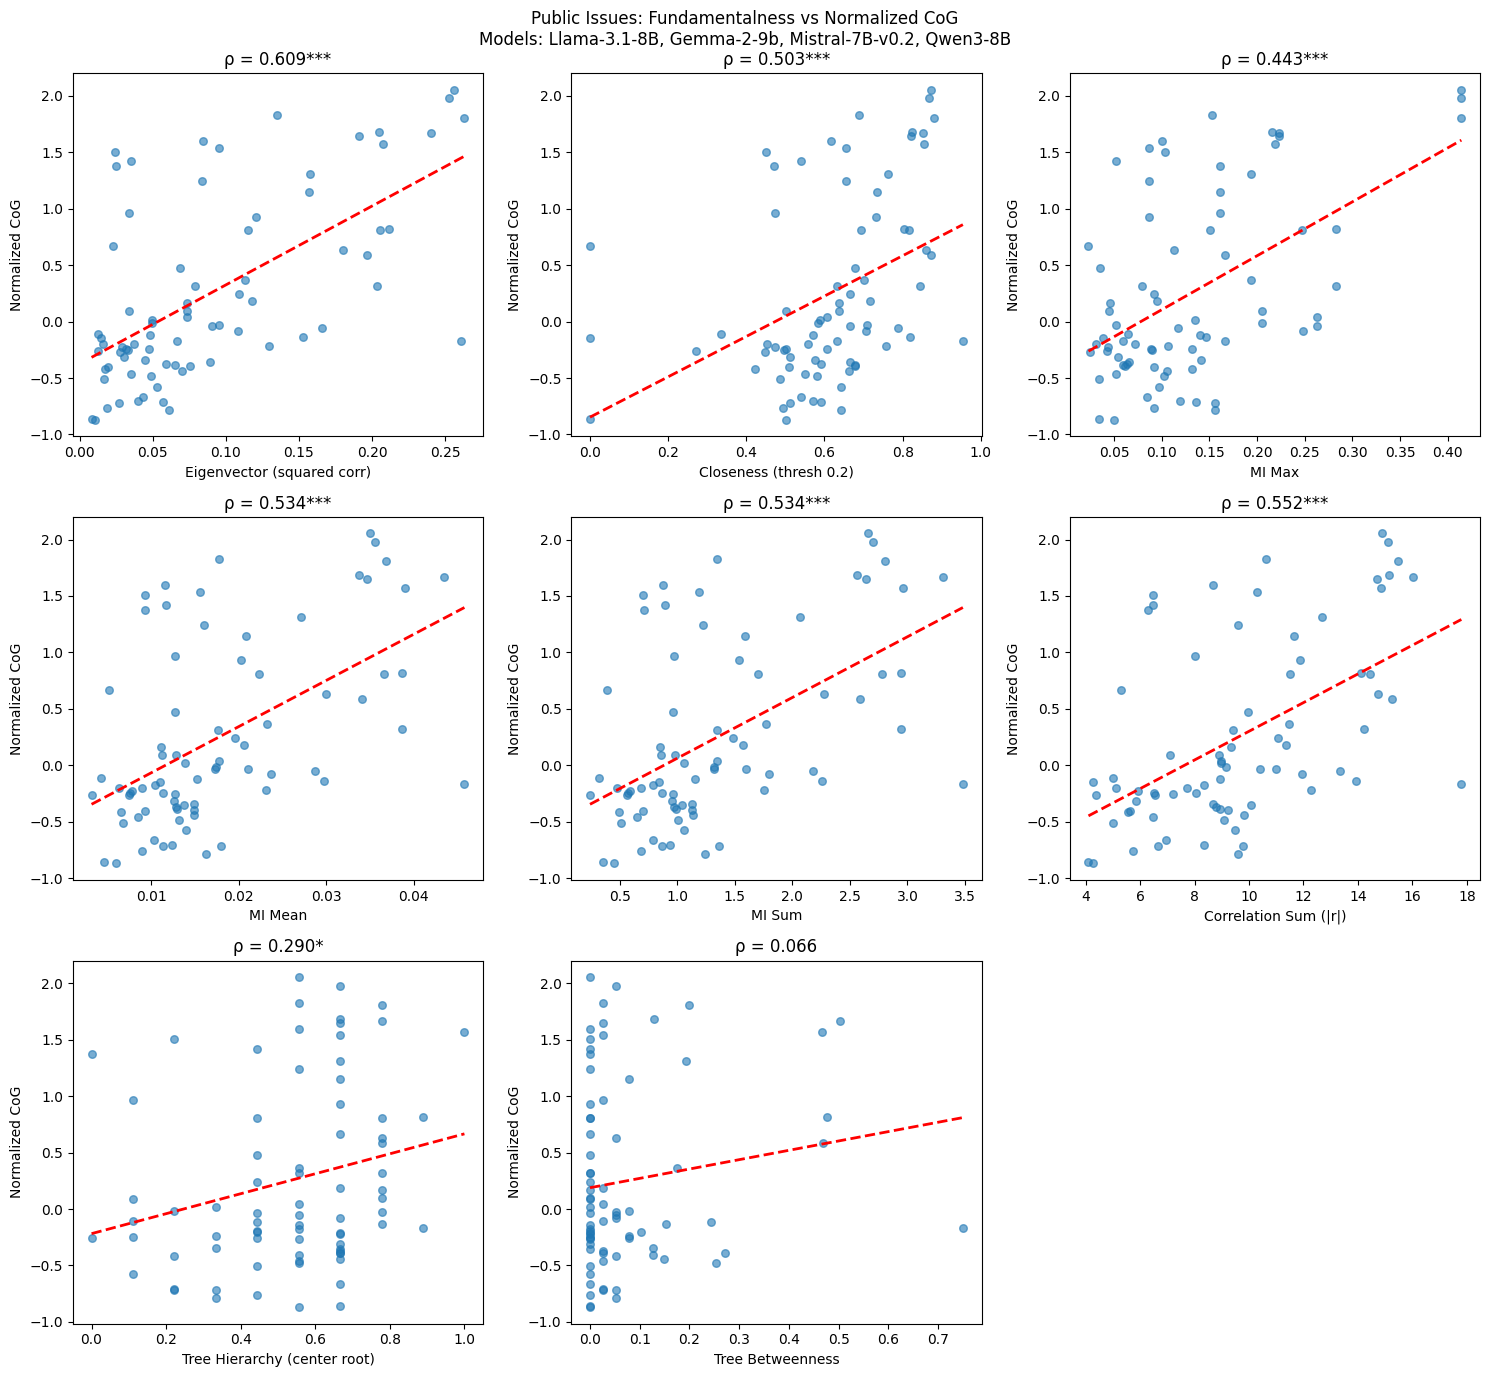

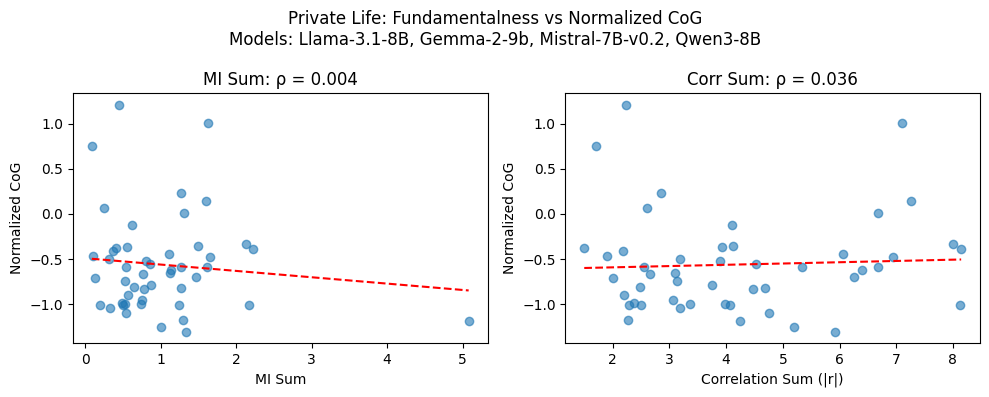

In [19]:
# Scatter plots for PUBLIC ISSUES - multiple measures
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.flatten()

cog_col = 'CoG_normalized'

# Measures to plot for public issues
public_measures = [
    ('complete_squared_eigenvector', 'Eigenvector (squared corr)'),
    ('thresh_0.2_closeness', 'Closeness (thresh 0.2)'),
    ('mi_max', 'MI Max'),
    ('mi_mean', 'MI Mean'),
    ('mi_sum', 'MI Sum'),
    ('corr_abs_sum', 'Correlation Sum (|r|)'),
    ('tree_center_hierarchy', 'Tree Hierarchy (center root)'),
    ('tree_betweenness', 'Tree Betweenness'),
]

# Add top measure if different from above
if len(sig_public) > 0:
    top_pub = sig_public.iloc[0]['measure']
    if top_pub not in [m[0] for m in public_measures]:
        public_measures.insert(0, (top_pub, f'Top: {top_pub}'))

for i, (measure, label) in enumerate(public_measures[:9]):
    ax = axes[i]
    if measure in merged_public.columns:
        valid = merged_public[[cog_col, measure]].dropna()
        ax.scatter(valid[measure], valid[cog_col], alpha=0.6, s=30)
        
        # Fit line
        z = np.polyfit(valid[measure], valid[cog_col], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid[measure].min(), valid[measure].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2)
        
        # Stats
        r, p_val = stats.spearmanr(valid[measure], valid[cog_col])
        ax.set_xlabel(label)
        ax.set_ylabel('Normalized CoG')
        ax.set_title(f'ρ = {r:.3f}{stars(p_val)}')
    else:
        ax.set_title(f'{measure}\n(not found)')
        ax.set_visible(False)

# Hide unused axes
for i in range(len(public_measures), 9):
    axes[i].set_visible(False)

plt.suptitle(f'Public Issues: Fundamentalness vs Normalized CoG\nModels: {", ".join(MODELS_TO_USE)}', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cog_fundamentalness_scatter_public_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Separate figure for Private Life
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Private - MI sum
ax = axes[0]
valid = merged_private[[cog_col, 'mi_sum']].dropna()
ax.scatter(valid['mi_sum'], valid[cog_col], alpha=0.6)
z = np.polyfit(valid['mi_sum'], valid[cog_col], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['mi_sum'].min(), valid['mi_sum'].max(), 100)
ax.plot(x_line, p(x_line), 'r--')
ax.set_xlabel('MI Sum')
ax.set_ylabel('Normalized CoG')
r, p_val = stats.spearmanr(valid['mi_sum'], valid[cog_col])
ax.set_title(f'MI Sum: ρ = {r:.3f}{stars(p_val)}')

# Private - corr_abs_sum
ax = axes[1]
valid = merged_private[[cog_col, 'corr_abs_sum']].dropna()
ax.scatter(valid['corr_abs_sum'], valid[cog_col], alpha=0.6)
z = np.polyfit(valid['corr_abs_sum'], valid[cog_col], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['corr_abs_sum'].min(), valid['corr_abs_sum'].max(), 100)
ax.plot(x_line, p(x_line), 'r--')
ax.set_xlabel('Correlation Sum (|r|)')
ax.set_ylabel('Normalized CoG')
r, p_val = stats.spearmanr(valid['corr_abs_sum'], valid[cog_col])
ax.set_title(f'Corr Sum: ρ = {r:.3f}{stars(p_val)}')

plt.suptitle(f'Private Life: Fundamentalness vs Normalized CoG\nModels: {", ".join(MODELS_TO_USE)}', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cog_fundamentalness_scatter_private.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results

In [20]:
# Save all results
corr_all.to_csv(RESULTS_DIR / 'cog_fundamentalness_correlations_all_measures.csv', index=False)
sig_results.to_csv(RESULTS_DIR / 'cog_fundamentalness_significant_all_measures.csv', index=False)
merged_public.to_csv(RESULTS_DIR / 'cog_fundamentalness_public_merged_all_measures.csv', index=False)
merged_private.to_csv(RESULTS_DIR / 'cog_fundamentalness_private_merged_all_measures.csv', index=False)

print("Files saved:")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_correlations_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_significant_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_public_merged_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_private_merged_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_scatter_all_measures.png'}")

Files saved:
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_correlations_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_significant_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_public_merged_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_private_merged_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_scatter_all_measures.png


## 9. Summary

In [21]:
print("="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n[Configuration]")
print(f"  Models used: {', '.join(MODELS_TO_USE)}")
print(f"  CoG normalization: Z-score within each model before averaging")

print(f"\n[Data]")
print(f"  Public Issues: {len(merged_public)} questions with CoG + fundamentalness")
print(f"  Private Life: {len(merged_private)} questions with CoG + fundamentalness")
print(f"  Total fundamentalness measures: {len(corr_public)} per category")

print(f"\n[Significant Correlations (p < 0.05)]")
print(f"  Public Issues: {n_public_sig} / {n_public_total} measures ({100*n_public_sig/n_public_total:.1f}%)")
print(f"  Private Life: {n_private_sig} / {n_private_total} measures ({100*n_private_sig/n_private_total:.1f}%)")

print(f"\n[Top Correlations by Category]")
if len(sig_public) > 0:
    top = sig_public.iloc[0]
    print(f"  Public Issues: {top['measure']} (ρ = {top['spearman_r']:.3f}{stars(top['spearman_p'])})")
if len(sig_private) > 0:
    top = sig_private.iloc[0]
    print(f"  Private Life: {top['measure']} (ρ = {top['spearman_r']:.3f}{stars(top['spearman_p'])})")
else:
    print(f"  Private Life: (No significant measures)")

print(f"\n[Interpretation]")
print("  Positive correlation: More fundamental questions → Deeper LLM encoding (higher CoG)")
print("  Public issues show strong relationship between network centrality and CoG depth")
print("  Private life questions show no significant relationship with CoG depth")

FINAL SUMMARY

[Configuration]
  Models used: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B
  CoG normalization: Z-score within each model before averaging

[Data]
  Public Issues: 76 questions with CoG + fundamentalness
  Private Life: 48 questions with CoG + fundamentalness
  Total fundamentalness measures: 72 per category

[Significant Correlations (p < 0.05)]
  Public Issues: 62 / 72 measures (86.1%)
  Private Life: 0 / 76 measures (0.0%)

[Top Correlations by Category]
  Public Issues: complete_squared_eigenvector (ρ = 0.609***)
  Private Life: (No significant measures)

[Interpretation]
  Positive correlation: More fundamental questions → Deeper LLM encoding (higher CoG)
  Public issues show strong relationship between network centrality and CoG depth
  Private life questions show no significant relationship with CoG depth


## 10. Per-Model Analysis (Pearson r)

Do the correlations hold when looking at each model individually?

We compute **Pearson correlation** between fundamentalness measures and raw CoG (not normalized) for each of the 4 models separately.

In [33]:
# Load per-model CoG data
df_llm_raw = pd.read_pickle(LLM_COMBINED_FILE)
df_llm_filtered = df_llm_raw[df_llm_raw['model'].isin(MODELS_TO_USE)].copy()

# COMPREHENSIVE list of key measures (all computed from GSS data)
key_measures = [
    # Tree measures - max_neighbor_mi root
    'tree_max_neighbor_mi_hierarchy', 'tree_max_neighbor_mi_depth', 'tree_max_neighbor_mi_subtree',
    
    # Tree measures - max_degree root
    'tree_max_degree_hierarchy', 
    'tree_max_degree_depth', 'tree_max_degree_subtree',
    
    # Tree measures - center root
    'tree_center_hierarchy', 
    'tree_center_depth', 'tree_center_subtree',
    
    # Tree betweenness
    'tree_betweenness',
    
    # MI-based
    'mi_max', 'mi_sum', 'mi_mean',
    
    # Correlation-based
    'corr_abs_sum', 'corr_abs_mean',
    
    # Complete network (standard)
    'complete_eigenvector', 'complete_harmonic', 'complete_closeness',
    'complete_pagerank', 'complete_strength', 'complete_betweenness', 'complete_log_betweenness',

    # Thresholded networks
    'thresh_0.1_harmonic', 'thresh_0.1_pagerank', 'thresh_0.1_strength', 'thresh_0.1_closeness', 'thresh_0.1_betweenness',
    'thresh_0.2_harmonic', 'thresh_0.2_pagerank', 'thresh_0.2_strength', 'thresh_0.2_closeness', 'thresh_0.2_betweenness',
]

def compute_permodel_correlations(fund_df, df_llm, category, measures):
    """Compute Pearson correlations for each model."""
    results = []
    
    for model in MODELS_TO_USE:
        # Get CoG for this model
        model_data = df_llm[df_llm['model'] == model]
        model_cog = model_data[model_data['category'] == category][['Topic', 'Polarization_CoG']]
        model_cog = model_cog.rename(columns={'Topic': 'variable', 'Polarization_CoG': 'CoG'})
        
        # Merge with fundamentalness
        merged = fund_df.merge(model_cog, on='variable', how='inner')
        
        for measure in measures:
            if measure not in merged.columns:
                continue
            valid = merged[['CoG', measure]].dropna()
            if len(valid) >= 10 and valid[measure].std() > 0:
                r, p = stats.pearsonr(valid['CoG'], valid[measure])
                results.append({
                    'model': model,
                    'measure': measure,
                    'n': len(valid),
                    'r': r,
                    'p': p
                })
    
    return pd.DataFrame(results)

# Compute for both categories
permodel_public = compute_permodel_correlations(fund_public, df_llm_filtered, 'public_issues', key_measures)
permodel_private = compute_permodel_correlations(fund_private, df_llm_filtered, 'private_life', key_measures)

print(f"Computed Pearson correlations for {len(MODELS_TO_USE)} models")
print(f"Public: {len(permodel_public)} measure-model combinations")
print(f"Private: {len(permodel_private)} measure-model combinations")

Computed Pearson correlations for 4 models
Public: 124 measure-model combinations
Private: 124 measure-model combinations


In [34]:
# PUBLIC ISSUES: Pearson r by model
print("="*100)
print("PUBLIC ISSUES: Pearson r (Fundamentalness vs CoG) by Model")
print("="*100)

pivot_pub = permodel_public.pivot(index='measure', columns='model', values='r')
pivot_pub_p = permodel_public.pivot(index='measure', columns='model', values='p')

# Sort by average correlation
pivot_pub['avg'] = pivot_pub[MODELS_TO_USE].mean(axis=1)
pivot_pub = pivot_pub.sort_values('avg', ascending=False)
pivot_pub_p = pivot_pub_p.reindex(pivot_pub.index)

print(f"\n{'Measure':<40s}", end="")
for model in MODELS_TO_USE:
    print(f"{model[:12]:>14s}", end="")
print(f"{'Avg':>10s}")
print("-" * 100)

for measure in pivot_pub.index:
    print(f"{measure:<40s}", end="")
    for model in MODELS_TO_USE:
        if model in pivot_pub.columns:
            r = pivot_pub.loc[measure, model]
            p = pivot_pub_p.loc[measure, model]
            if pd.notna(r):
                print(f"{r:>+10.3f}{stars(p):<4s}", end="")
            else:
                print(f"{'N/A':>14s}", end="")
    avg = pivot_pub.loc[measure, 'avg']
    print(f"{avg:>+10.3f}")

# Count significant per model
print("\n" + "-" * 100)
print(f"{'Significant (p<0.05)':<40s}", end="")
for model in MODELS_TO_USE:
    n_sig = (pivot_pub_p[model] < 0.05).sum()
    print(f"{n_sig:>14d}", end="")
print()

# Drop avg column for later use
pivot_pub = pivot_pub.drop(columns=['avg'])

PUBLIC ISSUES: Pearson r (Fundamentalness vs CoG) by Model

Measure                                   Llama-3.1-8B    Gemma-2-9b  Mistral-7B-v      Qwen3-8B       Avg
----------------------------------------------------------------------------------------------------
complete_harmonic                           +0.370**      +0.517***     +0.659***     +0.316**      +0.466
complete_eigenvector                        +0.292*       +0.540***     +0.670***     +0.276*       +0.444
thresh_0.1_harmonic                         +0.309**      +0.509***     +0.655***     +0.302**      +0.443
thresh_0.1_closeness                        +0.273*       +0.493***     +0.629***     +0.298**      +0.423
complete_closeness                          +0.283*       +0.493***     +0.619***     +0.296**      +0.423
corr_abs_mean                               +0.276*       +0.491***     +0.620***     +0.298**      +0.421
corr_abs_sum                                +0.276*       +0.491***     +0.620***     +0.2

In [35]:
permodel_public

,model,measure,n,r,p
0,Llama-3.1-8B,tree_max_neighbor_mi_hierarchy,76,0.147292,0.204186
1,Llama-3.1-8B,tree_max_neighbor_mi_depth,76,-0.147292,0.204186
2,Llama-3.1-8B,tree_max_neighbor_mi_subtree,76,0.034037,0.770365
3,Llama-3.1-8B,tree_max_degree_hierarchy,76,0.147292,0.204186
4,Llama-3.1-8B,tree_max_degree_depth,76,-0.147292,0.204186
...,...,...,...,...,...
119,Qwen3-8B,thresh_0.2_harmonic,76,0.260171,0.023222
120,Qwen3-8B,thresh_0.2_pagerank,76,0.300031,0.008458
121,Qwen3-8B,thresh_0.2_strength,76,0.306757,0.007034
122,Qwen3-8B,thresh_0.2_closeness,76,0.218555,0.057862


In [36]:
permodel_private

,model,measure,n,r,p
0,Llama-3.1-8B,tree_max_neighbor_mi_hierarchy,48,0.351274,0.014360
1,Llama-3.1-8B,tree_max_neighbor_mi_depth,48,-0.351274,0.014360
2,Llama-3.1-8B,tree_max_neighbor_mi_subtree,48,-0.015368,0.917430
3,Llama-3.1-8B,tree_max_degree_hierarchy,48,0.351274,0.014360
4,Llama-3.1-8B,tree_max_degree_depth,48,-0.351274,0.014360
...,...,...,...,...,...
119,Qwen3-8B,thresh_0.2_harmonic,48,0.157170,0.286041
120,Qwen3-8B,thresh_0.2_pagerank,48,0.133655,0.365119
121,Qwen3-8B,thresh_0.2_strength,48,0.366562,0.010391
122,Qwen3-8B,thresh_0.2_closeness,48,0.069893,0.636891


In [37]:
# PRIVATE LIFE: Pearson r by model
print("="*100)
print("PRIVATE LIFE: Pearson r (Fundamentalness vs CoG) by Model")
print("="*100)

pivot_priv = permodel_private.pivot(index='measure', columns='model', values='r')
pivot_priv_p = permodel_private.pivot(index='measure', columns='model', values='p')

# Sort by average correlation
pivot_priv['avg'] = pivot_priv[MODELS_TO_USE].mean(axis=1)
pivot_priv = pivot_priv.sort_values('avg', ascending=False)
pivot_priv_p = pivot_priv_p.reindex(pivot_priv.index)

print(f"\n{'Measure':<40s}", end="")
for model in MODELS_TO_USE:
    print(f"{model[:12]:>14s}", end="")
print(f"{'Avg':>10s}")
print("-" * 100)

for measure in pivot_priv.index:
    print(f"{measure:<40s}", end="")
    for model in MODELS_TO_USE:
        if model in pivot_priv.columns:
            r = pivot_priv.loc[measure, model]
            p = pivot_priv_p.loc[measure, model]
            if pd.notna(r):
                print(f"{r:>+10.3f}{stars(p):<4s}", end="")
            else:
                print(f"{'N/A':>14s}", end="")
    avg = pivot_priv.loc[measure, 'avg']
    print(f"{avg:>+10.3f}")

# Count significant per model
print("\n" + "-" * 100)
print(f"{'Significant (p<0.05)':<40s}", end="")
for model in MODELS_TO_USE:
    n_sig = (pivot_priv_p[model] < 0.05).sum()
    print(f"{n_sig:>14d}", end="")
print()

# Drop avg column for later use
pivot_priv = pivot_priv.drop(columns=['avg'])

PRIVATE LIFE: Pearson r (Fundamentalness vs CoG) by Model

Measure                                   Llama-3.1-8B    Gemma-2-9b  Mistral-7B-v      Qwen3-8B       Avg
----------------------------------------------------------------------------------------------------
thresh_0.2_strength                         -0.427**      -0.035        +0.364*       +0.367*       +0.067
complete_eigenvector                        -0.458**      -0.077        +0.369**      +0.417**      +0.063
tree_max_degree_hierarchy                   +0.351*       +0.082        +0.043        -0.305*       +0.043
tree_max_neighbor_mi_hierarchy              +0.351*       +0.082        +0.043        -0.305*       +0.043
complete_harmonic                           -0.432**      -0.048        +0.316*       +0.333*       +0.042
complete_closeness                          -0.444**      -0.061        +0.308*       +0.340*       +0.036
tree_center_depth                           -0.025        +0.096        -0.095        +0.16

SUMMARY: Per-Model Results (Pearson r)

[Public Issues]
Model                      Significant    Total        %      Avg r
-----------------------------------------------------------------
Llama-3.1-8B                        16       31    51.6%     +0.172
Gemma-2-9b                          24       31    77.4%     +0.302
Mistral-7B-v0.2                     28       31    90.3%     +0.394
Qwen3-8B                            17       31    54.8%     +0.205

[Private Life]
Model                      Significant    Total        %      Avg r
-----------------------------------------------------------------
Llama-3.1-8B                        19       31    61.3%     -0.250
Gemma-2-9b                           0       31     0.0%     -0.066
Mistral-7B-v0.2                      9       31    29.0%     +0.108
Qwen3-8B                            13       31    41.9%     +0.109


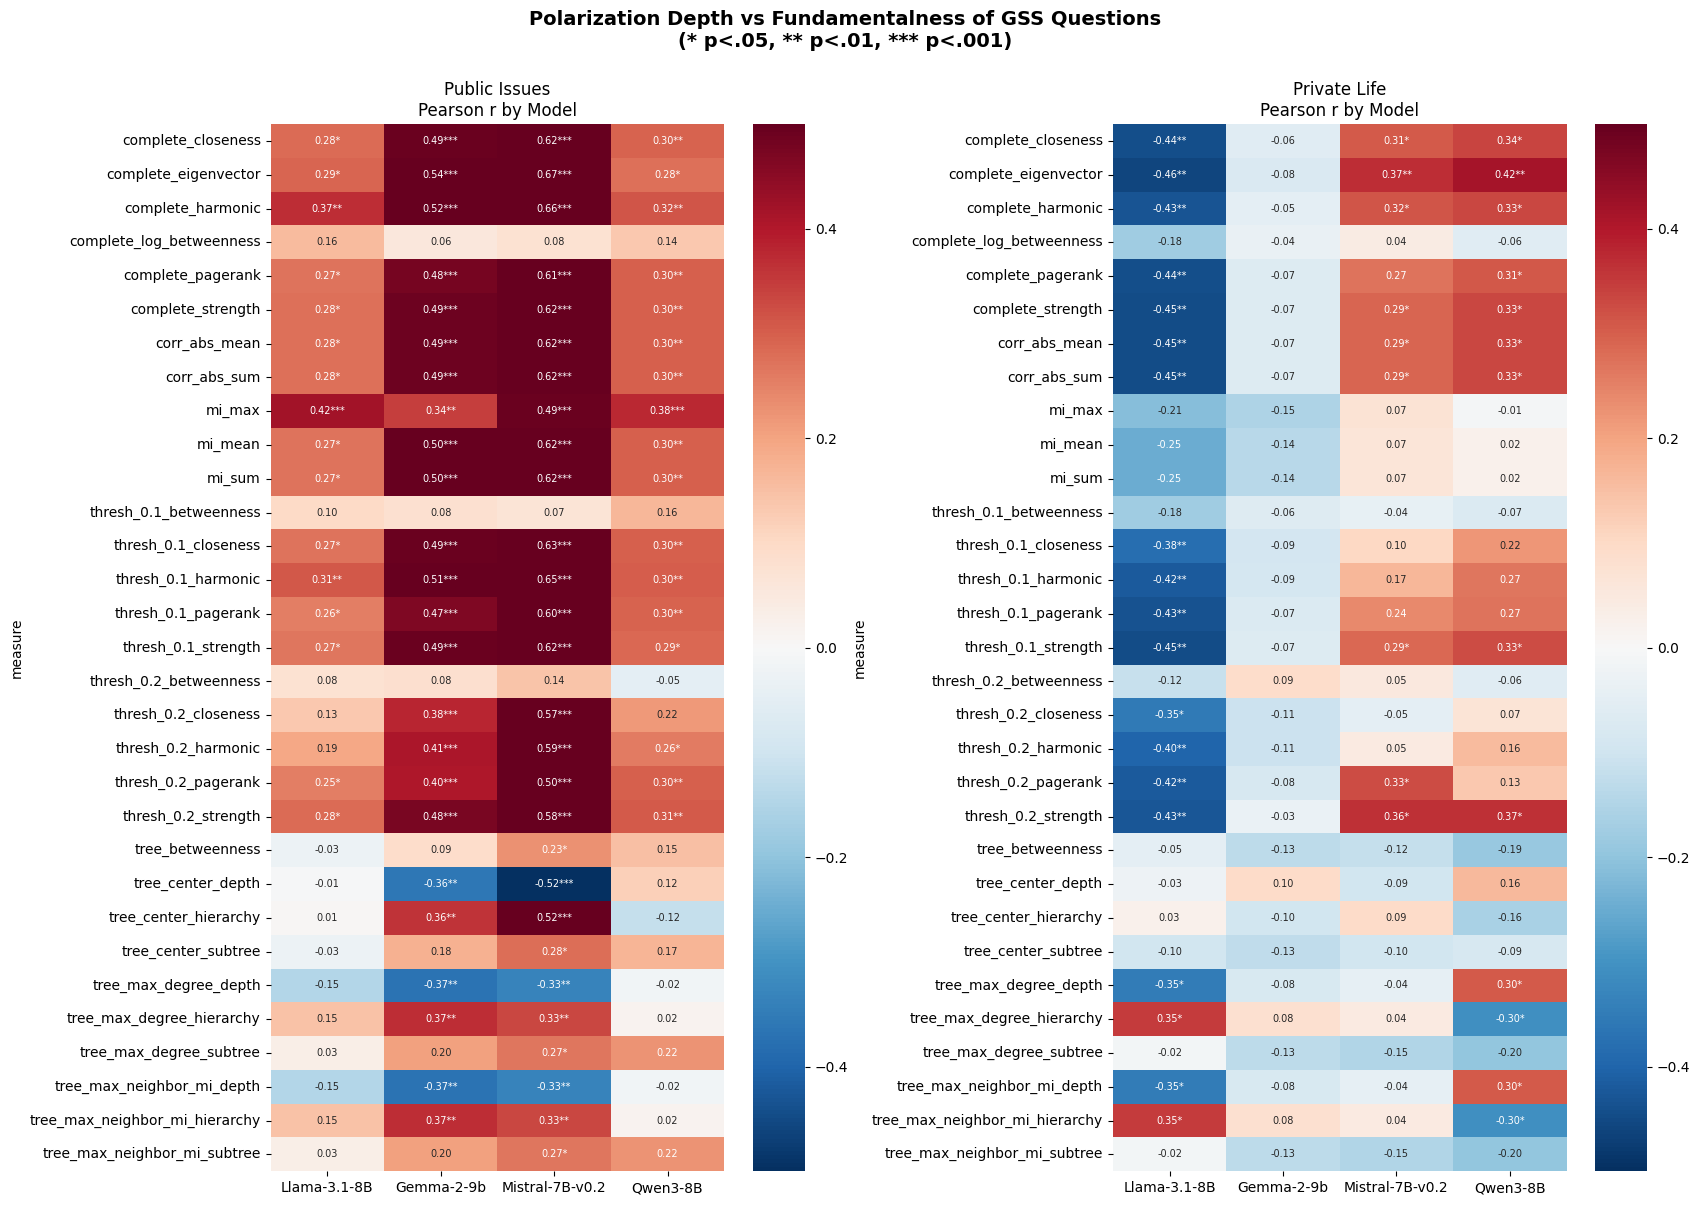


INTERPRETATION

Significance: * p < 0.05, ** p < 0.01, *** p < 0.001

If correlations are CONSISTENT across all 4 models → robust finding
If correlations are VARIABLE across models → model-specific effect  
If NO model shows significant correlations → spurious averaged result



In [38]:
# Summary and Heatmap Visualization with Significance Asterisks
print("="*100)
print("SUMMARY: Per-Model Results (Pearson r)")
print("="*100)

print("\n[Public Issues]")
print(f"{'Model':<25s} {'Significant':>12s} {'Total':>8s} {'%':>8s} {'Avg r':>10s}")
print("-" * 65)
for model in MODELS_TO_USE:
    n_sig = (pivot_pub_p[model] < 0.05).sum()
    n_total = pivot_pub_p[model].notna().sum()
    pct = 100 * n_sig / n_total if n_total > 0 else 0
    avg_r = pivot_pub[model].mean()
    print(f"{model:<25s} {n_sig:>12d} {n_total:>8d} {pct:>7.1f}% {avg_r:>+10.3f}")

print("\n[Private Life]")
print(f"{'Model':<25s} {'Significant':>12s} {'Total':>8s} {'%':>8s} {'Avg r':>10s}")
print("-" * 65)
for model in MODELS_TO_USE:
    n_sig = (pivot_priv_p[model] < 0.05).sum()
    n_total = pivot_priv_p[model].notna().sum()
    pct = 100 * n_sig / n_total if n_total > 0 else 0
    avg_r = pivot_priv[model].mean()
    print(f"{model:<25s} {n_sig:>12d} {n_total:>8d} {pct:>7.1f}% {avg_r:>+10.3f}")

# Helper function to create annotation with significance stars
def create_annotated_heatmap(r_df, p_df, models):
    """Create annotation strings with significance asterisks.
    * p < 0.05, ** p < 0.01, *** p < 0.001
    """
    annot = pd.DataFrame('', index=r_df.index, columns=models)
    for measure in r_df.index:
        for model in models:
            r = r_df.loc[measure, model]
            p = p_df.loc[measure, model]
            if pd.isna(r):
                annot.loc[measure, model] = ''
            else:
                # Determine significance level
                if p < 0.001:
                    sig = '***'
                elif p < 0.01:
                    sig = '**'
                elif p < 0.05:
                    sig = '*'
                else:
                    sig = ''
                annot.loc[measure, model] = f'{r:.2f}{sig}'
    return annot

# Create heatmaps with significance annotations
fig, axes = plt.subplots(1, 2, figsize=(17, 12))

# Public Issues heatmap (alphabetical order)
ax = axes[0]
alpha_pub = pivot_pub[MODELS_TO_USE].sort_index()
alpha_pub_p = pivot_pub_p[MODELS_TO_USE].sort_index()
annot_pub = create_annotated_heatmap(alpha_pub, alpha_pub_p, MODELS_TO_USE)
sns.heatmap(alpha_pub, annot=annot_pub, fmt='', cmap='RdBu_r', 
            center=0, vmin=-0.5, vmax=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Public Issues\nPearson r by Model')
ax.set_xlabel('')

# Private Life heatmap (alphabetical order)
ax = axes[1]
alpha_priv = pivot_priv[MODELS_TO_USE].sort_index()
alpha_priv_p = pivot_priv_p[MODELS_TO_USE].sort_index()
annot_priv = create_annotated_heatmap(alpha_priv, alpha_priv_p, MODELS_TO_USE)
sns.heatmap(alpha_priv, annot=annot_priv, fmt='', cmap='RdBu_r', 
            center=0, vmin=-0.5, vmax=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Private Life\nPearson r by Model')
ax.set_xlabel('')

plt.suptitle('Polarization Depth vs Fundamentalness of GSS Questions\n(* p<.05, ** p<.01, *** p<.001)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cog_fundamentalness_permodel_heatmap_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*100)
print("INTERPRETATION")
print("="*100)
print("""
Significance: * p < 0.05, ** p < 0.01, *** p < 0.001

If correlations are CONSISTENT across all 4 models → robust finding
If correlations are VARIABLE across models → model-specific effect  
If NO model shows significant correlations → spurious averaged result
""")